# Notebook with data visualization to understand skew in the protected attributes and label on adult data (for a unique file)

### Imports

In [1]:
import matplotlib.pyplot as plt 
import pandas as pd
import seaborn as sns

from falsb4mpa.dataset.load_data import load_data

### Adult data binarized without aggregation

In [2]:
data = pd.read_csv("../../../data/processed/adult/adult_mpa_bin_wout_agg.csv", index_col='Unnamed: 0')

In [3]:
len(data.index)

45222

In [4]:
data.head()

,age,sex,race,education_ 10th,education_ 11th,education_ 12th,education_ 1st-4th,education_ 5th-6th,education_ 7th-8th,education_ 9th,...,native-country_ Puerto-Rico,native-country_ Scotland,native-country_ South,native-country_ Taiwan,native-country_ Thailand,native-country_ Trinadad&Tobago,native-country_ United-States,native-country_ Vietnam,native-country_ Yugoslavia,income
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
1,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
2,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
3,1,1,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
data['sex'].value_counts()

sex
1    30527
0    14695
Name: count, dtype: int64

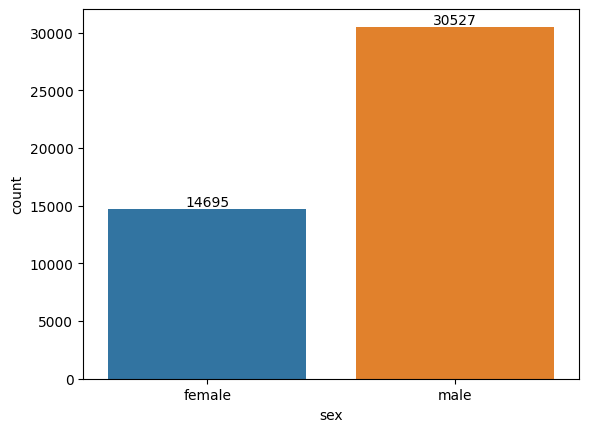

In [6]:
cols = ['sex', 'count']
sex = ['female', 'male']
res_df = pd.DataFrame(columns=cols, dtype='object')

train_counts = data['sex'].value_counts()
train_df = pd.DataFrame(
    data=[
        [sex[0], train_counts[0]],
        [sex[1], train_counts[1]]
    ],
    columns=cols
)

res_df = pd.concat([train_df])

for i in res_df.index:
    count = res_df.loc[i, 'count']
    y = res_df.loc[i, 'count']
    plt.annotate(count, (i, y), ha="center", va="bottom")

sns.barplot(x='sex',y='count',data=res_df,hue='sex', dodge=False)
# plt.legend(loc="upper right")
plt.legend([], frameon=False)
plt.show()


In [7]:
data['income'].value_counts()

income
0    34014
1    11208
Name: count, dtype: int64

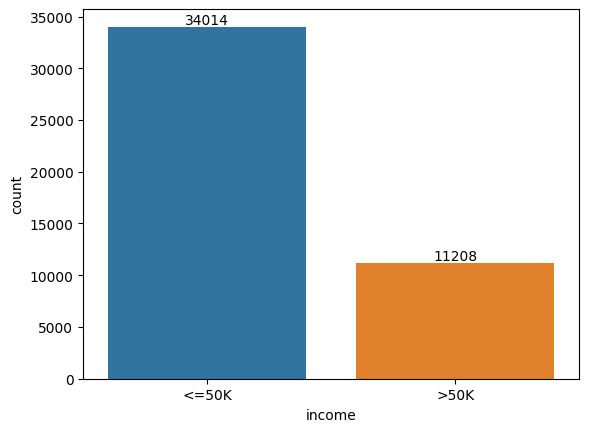

In [8]:
cols = ['income', 'count']
income = ['<=50K', '>50K']
res_df = pd.DataFrame(columns=cols, dtype='object')

train_counts = data['income'].value_counts()
train_df = pd.DataFrame(
    data=[
        [income[0], train_counts[0]],
        [income[1], train_counts[1]]
    ],
    columns=cols
)

res_df = pd.concat([train_df])

for i in res_df.index:
    count = res_df.loc[i, 'count']
    y = res_df.loc[i, 'count']
    plt.annotate(count, (i, y), ha="center", va="bottom")

sns.barplot(x='income',y='count',data=res_df,hue='income', dodge=False)
# plt.legend(loc="upper right")
plt.legend([], frameon=False)
plt.show()

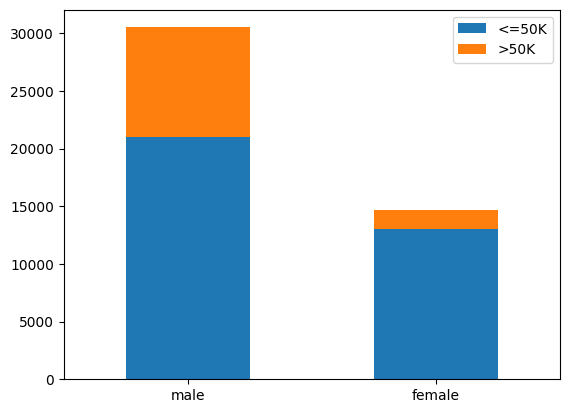

In [9]:
great_income = data[data['income'] == 1]
man_great = len(great_income[great_income['sex'] == 1].index)
woman_great = len(great_income[great_income['sex'] == 0].index)

lower_income = data[data['income'] == 0]
man_low = len(lower_income[lower_income['sex'] == 1].index)
woman_low = len(lower_income[lower_income['sex'] == 0].index)


res_df = pd.DataFrame(
    {
        '<=50K': [man_low, woman_low],
        '>50K': [man_great, woman_great],
    },
    index=['male', 'female']
)

res_df.plot(kind='bar', stacked=True)#, color=['red', 'pink'])
plt.legend(loc="upper right")
plt.xticks(rotation=0)
plt.show()

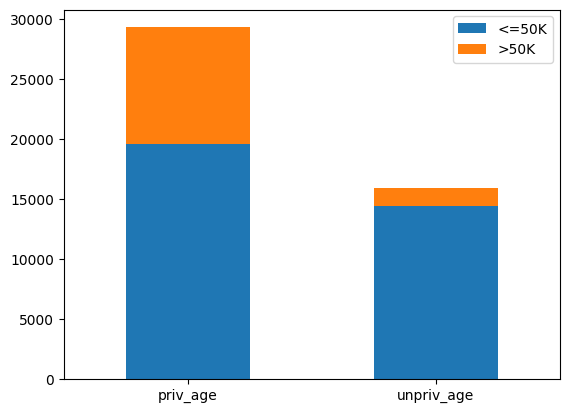

In [10]:
great_income = data[data['income'] == 1]
privileged_age_great = len(great_income[great_income['age'] == 1].index)
unprivileged_age_great = len(great_income[great_income['age'] == 0].index)

lower_income = data[data['income'] == 0]
unpriv_age_great = len(lower_income[lower_income['age'] == 1].index)
unpriv_age_low = len(lower_income[lower_income['age'] == 0].index)


res_df = pd.DataFrame(
    {
        '<=50K': [unpriv_age_great, unpriv_age_low],
        '>50K': [privileged_age_great, unprivileged_age_great],
    },
    index=['priv_age', 'unpriv_age']
)

res_df.plot(kind='bar', stacked=True)#, color=['red', 'pink'])
plt.legend(loc="upper right")
plt.xticks(rotation=0)
plt.show()

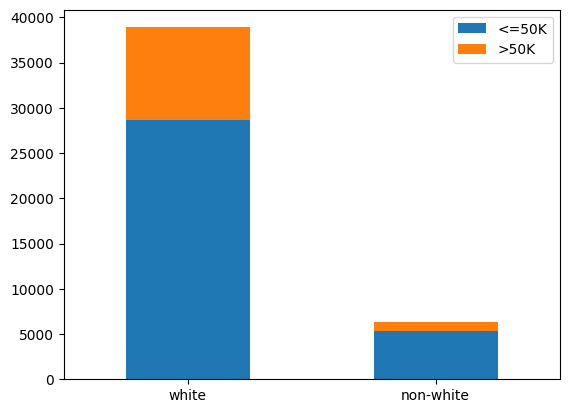

In [11]:
great_income = data[data['income'] == 1]
white_great = len(great_income[great_income['race'] == 1].index)
non_white_great = len(great_income[great_income['race'] == 0].index)

lower_income = data[data['income'] == 0]
white_low = len(lower_income[lower_income['race'] == 1].index)
non_white_low = len(lower_income[lower_income['race'] == 0].index)


res_df = pd.DataFrame(
    {
        '<=50K': [white_low, non_white_low],
        '>50K': [white_great, non_white_great],
    },
    index=['white', 'non-white']
)

res_df.plot(kind='bar', stacked=True)#, color=['red', 'pink'])
plt.legend(loc="upper right")
plt.xticks(rotation=0)
plt.show()

### Adult data binarized with aggregation

In [12]:
data = pd.read_csv("../../../data/processed/adult/adult_mpa_bin_with_agg.csv", index_col='Unnamed: 0')

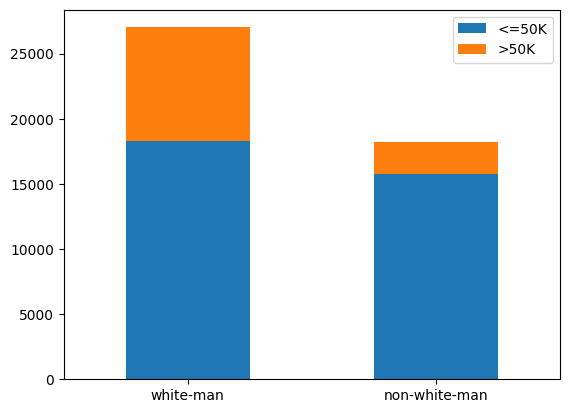

In [13]:
great_income = data[data['income'] == 1]
white_great = len(great_income[great_income['sex-race'] == 1].index)
non_white_great = len(great_income[great_income['sex-race'] == 0].index)

lower_income = data[data['income'] == 0]
white_low = len(lower_income[lower_income['sex-race'] == 1].index)
non_white_low = len(lower_income[lower_income['sex-race'] == 0].index)


res_df = pd.DataFrame(
    {
        '<=50K': [white_low, non_white_low],
        '>50K': [white_great, non_white_great],
    },
    index=['white-man', 'non-white-man']
)

res_df.plot(kind='bar', stacked=True)#, color=['red', 'pink'])
plt.legend(loc="upper right")
plt.xticks(rotation=0)
plt.show()

### Adult data cat with aggregation

In [14]:
data = pd.read_csv("../../../data/processed/adult/adult_mpa_cat_with_agg.csv", index_col='Unnamed: 0')

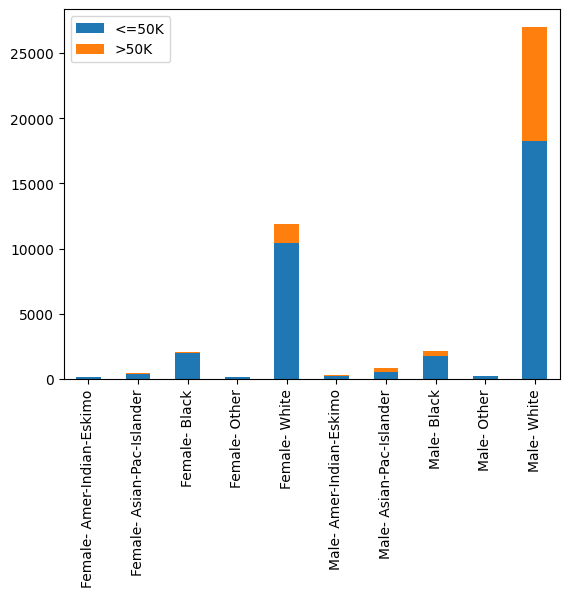

In [15]:
cols = ['sex-race_ Female- Amer-Indian-Eskimo', 'sex-race_ Female- Asian-Pac-Islander','sex-race_ Female- Black','sex-race_ Female- Other','sex-race_ Female- White','sex-race_ Male- Amer-Indian-Eskimo','sex-race_ Male- Asian-Pac-Islander','sex-race_ Male- Black','sex-race_ Male- Other','sex-race_ Male- White', 'count', 'income']
races = ['Female- Amer-Indian-Eskimo', 'Female- Asian-Pac-Islander','Female- Black','Female- Other','Female- White','Male- Amer-Indian-Eskimo','Male- Asian-Pac-Islander','Male- Black','Male- Other','Male- White',]
res_df = pd.DataFrame(columns=cols, dtype=object)

great_income = data[data['income'] == 1]
raw_subset = great_income[['sex-race_ Female- Amer-Indian-Eskimo', 'sex-race_ Female- Asian-Pac-Islander','sex-race_ Female- Black','sex-race_ Female- Other','sex-race_ Female- White','sex-race_ Male- Amer-Indian-Eskimo','sex-race_ Male- Asian-Pac-Islander','sex-race_ Male- Black','sex-race_ Male- Other','sex-race_ Male- White']]
subset = pd.get_dummies(raw_subset).idxmax(1).str.replace('sex-race_ ', '')

races_great = subset.value_counts()
# print(races_great)

low_income = data[data['income'] == 0]
raw_subset = low_income[['sex-race_ Female- Amer-Indian-Eskimo', 'sex-race_ Female- Asian-Pac-Islander','sex-race_ Female- Black','sex-race_ Female- Other','sex-race_ Female- White','sex-race_ Male- Amer-Indian-Eskimo','sex-race_ Male- Asian-Pac-Islander','sex-race_ Male- Black','sex-race_ Male- Other','sex-race_ Male- White']]
subset = pd.get_dummies(raw_subset).idxmax(1).str.replace('sex-race_ ', '')

races_low = subset.value_counts()
# print(races_low)

res_df = pd.DataFrame(
    {
        '<=50K': races_low,
        '>50K': races_great,
    },
    index=races
)

res_df.plot(kind='bar', stacked=True)
plt.legend(loc="upper left")
plt.xticks(rotation='vertical')
plt.show()

In [19]:
data["sex-race_ Male- Other"].value_counts()

sex-race_ Male- Other
0    44995
1      227
Name: count, dtype: int64

### Adult data cat without aggregation

In [16]:
data = pd.read_csv("../../../data/processed/adult/adult_mpa_cat_wout_agg.csv", index_col='Unnamed: 0')

/var/folders/nx/ktkztyln3xn8f8j2qrfpjrlh0000gn/T/ipykernel_9861/2283381478.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  [races[0], train_counts[0]],
/var/folders/nx/ktkztyln3xn8f8j2qrfpjrlh0000gn/T/ipykernel_9861/2283381478.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  [races[1], train_counts[1]],
/var/folders/nx/ktkztyln3xn8f8j2qrfpjrlh0000gn/T/ipykernel_9861/2283381478.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[po

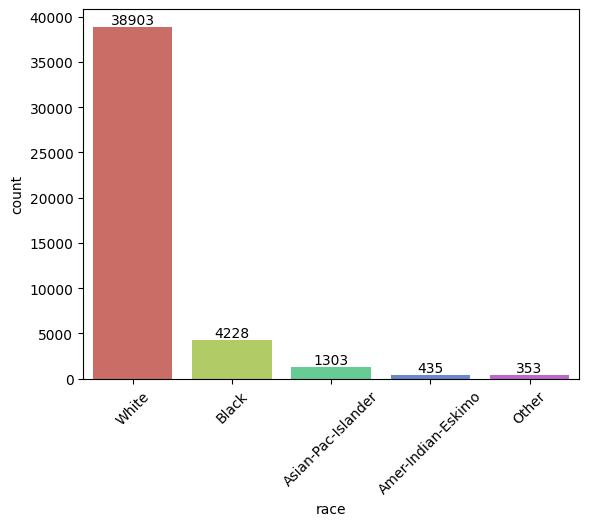

In [17]:
raw_subset = data[['race_ Amer-Indian-Eskimo','race_ Asian-Pac-Islander','race_ Black','race_ Other','race_ White']]
subset = pd.get_dummies(raw_subset).idxmax(1).str.replace('race_ ', '')

cols = ['race', 'count']
races = subset.unique()

res_df = pd.DataFrame(columns=cols, dtype=object)

train_counts = subset.value_counts()
train_df = pd.DataFrame(
    data=[
        [races[0], train_counts[0]],
        [races[1], train_counts[1]],
        [races[2], train_counts[2]],
        [races[3], train_counts[3]],
        [races[4], train_counts[4]]
    ],
    columns=cols
)

res_df = pd.concat([train_df])

for i in res_df.index:
    count = res_df.loc[i, 'count']
    y = res_df.loc[i, 'count']
    plt.annotate(count, (i, y), ha="center", va="bottom")

sns.barplot(x='race',y='count',data=res_df,hue='race', dodge=False, palette='hls')
plt.xticks(rotation=45)
# plt.legend(bbox_to_anchor=(1.46,1.02), loc="upper right")
plt.legend([], frameon=False)
plt.show()


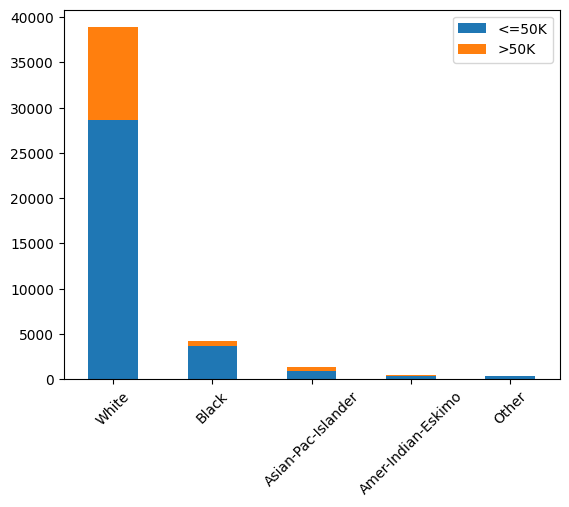

In [18]:
cols = ['race', 'count', 'income']
races = ['White', 'Black', 'Asian-Pac-Islander', 'Amer-Indian-Eskimo', 'Other']
res_df = pd.DataFrame(columns=cols, dtype=object)

great_income = data[data['income'] == 1]
raw_subset = great_income[['race_ Amer-Indian-Eskimo','race_ Asian-Pac-Islander','race_ Black','race_ Other','race_ White']]
subset = pd.get_dummies(raw_subset).idxmax(1).str.replace('race_ ', '')

races_great = subset.value_counts()

low_income = data[data['income'] == 0]
raw_subset = low_income[['race_ Amer-Indian-Eskimo','race_ Asian-Pac-Islander','race_ Black','race_ Other','race_ White']]
subset = pd.get_dummies(raw_subset).idxmax(1).str.replace('race_ ', '')

races_low = subset.value_counts()

res_df = pd.DataFrame(
    {
        '<=50K': races_low,
        '>50K': races_great,
    },
    index=races
)

res_df.plot(kind='bar', stacked=True)
plt.legend(loc="upper right")
plt.xticks(rotation=45)
plt.show()